In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

## Lab 2: Image Stitching with Homographies

In this lab, we will explore image stitching and panorama creation. You will use a homography to register two images together, and implement bilinear interpolation to help accomplish this. As part of the lab, you will also explore image enhancement strategies to improve the quality of image stitching at the seam (the join between two images) relying on your knowledge of image brightness and human perception of this. Collectively, tasks 1-5 will provide a final stitched image. In task 6, you will apply the same code written in tasks 1-5 to create a panorama image using your own photos.

* Task 1: Draw test points on the left image
* Task 2: Use a homography to find the location of these points in the right image
* Task 3: Bilinear interpolation of the right image pixels
* Task 4: Image stitching 
* Task 5: Better blending
* Task 6: Now try your own!

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

# Task 1: Draw test points on the left image

Draw the following points on the left image as red crosses. Display the resulting image.

{446 , 499, 1}, {383, 590, 1}, {296 , 499, 1}, {282, 511, 1}, {401 , 508, 1}

Recall from lectures that these 3-element homogeneous coordinates can be transformed to 2D image pixel coordinates by dividing the first and second elements by the third (needed for later tasks).

In [2]:
# Load the left image
left = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)

# Convert to display format
left_display = cv2.cvtColor(left, cv2.COLOR_GRAY2BGR)

# Define test points in homogeneous coordinates
test_points_homo = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
], dtype=np.float32)

# Convert homogeneous coordinates to 2D image pixel coordinates
test_points_2d = test_points_homo[:, :2] / test_points_homo[:, 2:3]

# Draw red crosses on the left image
cross_size = 10
cross_thickness = 2
for point in test_points_2d:
    x, y = int(point[0]), int(point[1])
    # Draw horizontal line
    cv2.line(left_display, (x - cross_size, y), (x + cross_size, y), (0, 0, 255), cross_thickness)
    # Draw vertical line
    cv2.line(left_display, (x, y - cross_size), (x, y + cross_size), (0, 0, 255), cross_thickness)

### Displaying the Given Points on the Left Image

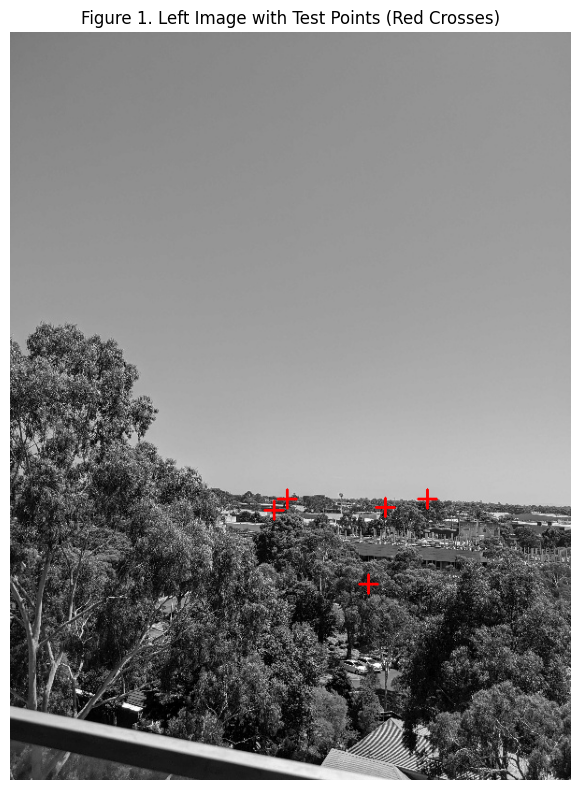

In [6]:
# Display the left image with test points
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(left_display, cv2.COLOR_BGR2RGB))
plt.title('Figure 1. Left Image with Test Points (Red Crosses)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 2: Use Homography to find right image points


The following homography transforms pixel coordinates between the left and right images as
$$ x_R = H x_L $$

\begin{bmatrix}
1.6011 & 0.0277 & -393.5701 \\
0.3242 & 1.5119 & -228.8918 \\
0.0009 & 0.0002 & 1.0000
\end{bmatrix}

Apply the homography to transform the left image points in Task 1 to their corresponding locations in the right image. Draw the transformed points as red crosses on the right image. Check your result before moving on.


In [10]:
# Load the right image
right = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Convert right image to display format and draw transformed points
right_display = cv2.cvtColor(right, cv2.COLOR_GRAY2BGR)

# Define the homography matrix H
H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002, 1.0000]
], dtype=np.float32)

# Transform the test points using the homography: x_R = H @ x_L
# Convert 2D points to homogeneous coordinates for transformation
test_points_homo_transformed = (H @ test_points_homo.T).T

# Convert transformed homogeneous coordinates back to 2D
test_points_transformed_2d = test_points_homo_transformed[:, :2] / test_points_homo_transformed[:, 2:3]

### Displaying the Transformed Points on the Right Image

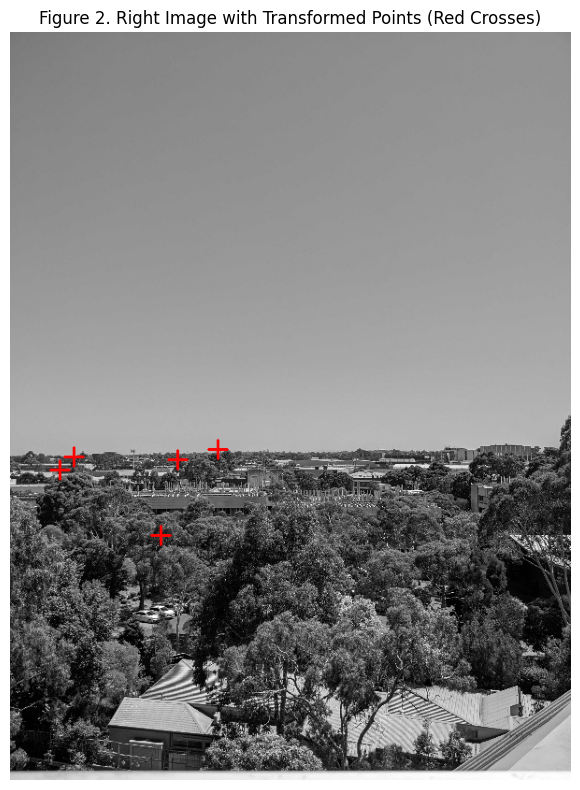

In [12]:
# Draw red crosses on the right image at transformed locations
for i, point in enumerate(test_points_transformed_2d):
    x, y = int(point[0]), int(point[1])
    if 0 <= x < right.shape[1] and 0 <= y < right.shape[0]:
        # Draw horizontal line
        cv2.line(right_display, (x - cross_size, y), (x + cross_size, y), (0, 0, 255), cross_thickness)
        # Draw vertical line
        cv2.line(right_display, (x, y - cross_size), (x, y + cross_size), (0, 0, 255), cross_thickness)

# Display the right image with transformed points
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(right_display, cv2.COLOR_BGR2RGB))
plt.title('Figure 2. Right Image with Transformed Points (Red Crosses)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 3: Bilinear interpolation of the right image

The transformed coordinates can be in between pixel locations. Write a bilinear interpolation function to compute the intensity of the transformed pixel coordinate in right.jpg using intensity values from neighbouring pixel locations. Print the interpolated intensity value for each transformed point in Task 2. The first point should be around 176 whereas the last point should be around 73.

HINT: The bilinear interpolation function should take the transformed pixel coordinate and the intensity values of its four neighbours as input arguments, and should output the interpolated intensity value.

In [13]:
# Write your code here
def bilinear_interpolation(x, y, I_tl, I_tr, I_bl, I_br):
    """
    Perform bilinear interpolation at position (x, y).
    
    Args:
        x, y: Continuous coordinates within [0, 1]
        I_tl: Intensity at top-left corner
        I_tr: Intensity at top-right corner
        I_bl: Intensity at bottom-left corner
        I_br: Intensity at bottom-right corner
    
    Returns:
        Interpolated intensity value
    """
    # Bilinear interpolation formula:
    # I(x,y) = (1-x)(1-y)*I_tl + x(1-y)*I_tr + (1-x)y*I_bl + x*y*I_br
    
    one_minus_x = 1 - x
    one_minus_y = 1 - y
    
    interpolated = (one_minus_x * one_minus_y * I_tl +
                   x * one_minus_y * I_tr +
                   one_minus_x * y * I_bl +
                   x * y * I_br)
    
    return interpolated


def get_pixel_bilinear(image, x, y):
    """
    Get interpolated pixel value at continuous coordinates (x, y) in the image.
    
    Args:
        image: Input image (grayscale)
        x, y: Continuous coordinates
    
    Returns:
        Interpolated intensity value, or None if out of bounds
    """
    # Get the integer and fractional parts
    x_int, y_int = int(x), int(y)
    x_frac, y_frac = x - x_int, y - y_int
    
    height, width = image.shape
    
    # Check if we're close enough to the boundary for interpolation
    if x_int < 0 or x_int >= width - 1 or y_int < 0 or y_int >= height - 1:
        return None
    
    # Get the four neighbor pixels
    I_tl = float(image[y_int, x_int])
    I_tr = float(image[y_int, x_int + 1])
    I_bl = float(image[y_int + 1, x_int])
    I_br = float(image[y_int + 1, x_int + 1])
    
    # Perform bilinear interpolation
    interpolated_value = bilinear_interpolation(x_frac, y_frac, I_tl, I_tr, I_bl, I_br)
    
    return interpolated_value

### Showing the results of the billinear interpolation functions written above

In [21]:
# Apply bilinear interpolation to each transformed point
print("Interpolated intensity values at transformed points:")
print("Point | Transformed Coordinates | Interpolated Intensity")
print("-" * 60)

interpolated_values = []
for i, point in enumerate(test_points_transformed_2d):
    x, y = point[0], point[1]
    intensity = get_pixel_bilinear(right, x, y)
    
    if intensity is not None:
        interpolated_values.append(intensity)
        print(f"{i+1:5d} | ({x:7.2f}, {y:7.2f})      | {intensity:7.2f}")
    else:
        print(f"{i+1:5d} | ({x:7.2f}, {y:7.2f})      | Out of bounds")

print("\n" + "="*60)

print(f"First point interpolated intensity: {interpolated_values[0]:.2f} (expected ~176)")
print(f"Last point interpolated intensity:  {interpolated_values[-1]:.2f} (expected ~73)")

Interpolated intensity values at transformed points:
Point | Transformed Coordinates | Interpolated Intensity
------------------------------------------------------------
    1 | ( 222.72,  446.40)      |  176.00
    2 | ( 161.34,  538.25)      |   38.47
    3 | (  68.93,  454.92)      |   69.83
    4 | (  53.17,  468.37)      |   58.19
    5 | ( 179.52,  457.54)      |   74.51

First point interpolated intensity: 176.00 (expected ~176)
Last point interpolated intensity:  74.51 (expected ~73)


# Task 4: Image stitching

Create a 1200x800 (width x height) image and fill the left hand side of this image with the left image. This stitched image will use the left image coordinate system (xl) throughout the stitching process. Next, fill in the remaining pixels on the RHS by transforming their pixel coordinates (left image coordinates) to the right image coordinates via the homography from Task 2 and determining the intensity using your bilinear interpolation implementation. If the right pixel  coordinate is valid, generate the pixel value using bilinear interpolation, but if the right pixel coordinate is invalid, use a pixel value of zero. Display the stitching results. It should look like a wide-angle image with a visible seam where the two images join.

In [25]:
# Get image dimensions
left_height, left_width = left.shape
right_height, right_width = right.shape

print(f"Left image size: {left_width} x {left_height}")
print(f"Right image size: {right_width} x {right_height}")

# Create 1200x800 canvas and fill left side with left image
canvas_width, canvas_height = 1200, 800
stitched = np.zeros((canvas_height, canvas_width), dtype=np.uint8)
stitched[:left_height, :left_width] = left

# Vectorized: build grid of all canvas pixel coordinates (Week 4 pattern: K@X)
xs, ys = np.meshgrid(np.arange(canvas_width), np.arange(canvas_height))

# Apply H directly (x_R = H @ x_L) to find each canvas pixel's location in right image
denom   = H[2,0]*xs + H[2,1]*ys + H[2,2]
x_right = (H[0,0]*xs + H[0,1]*ys + H[0,2]) / denom
y_right = (H[1,0]*xs + H[1,1]*ys + H[1,2]) / denom

# Vectorized bilinear interpolation
def bilinear_vectorized(image, x, y):
    h, w = image.shape
    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x_frac = x - x0
    y_frac = y - y0

    valid = (x0 >= 0) & (x0 < w-1) & (y0 >= 0) & (y0 < h-1)
    out = np.zeros_like(x, dtype=np.float32)

    xv, yv = x0[valid], y0[valid]
    dx, dy = x_frac[valid], y_frac[valid]

    I_tl = image[yv,   xv  ].astype(np.float32)
    I_tr = image[yv,   xv+1].astype(np.float32)
    I_bl = image[yv+1, xv  ].astype(np.float32)
    I_br = image[yv+1, xv+1].astype(np.float32)

    out[valid] = ((1-dx)*(1-dy)*I_tl +
                     dx *(1-dy)*I_tr +
                  (1-dx)*   dy *I_bl +
                     dx *   dy *I_br)
    return out, valid

warped, valid = bilinear_vectorized(right, x_right, y_right)

# Only fill RHS (x >= left_width) with right image pixels
rhs_mask = np.zeros((canvas_height, canvas_width), dtype=bool)
rhs_mask[:, left_width:] = valid[:, left_width:]
stitched[rhs_mask] = np.clip(warped[rhs_mask], 0, 255).astype(np.uint8)

Left image size: 600 x 800
Right image size: 600 x 800


### Displaying the stitched image

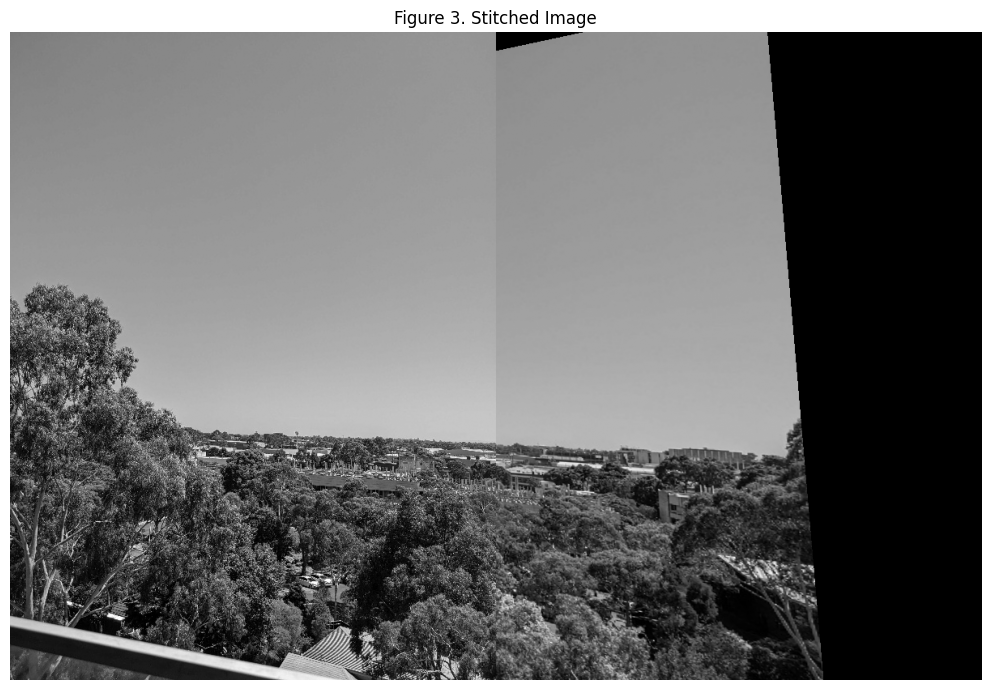

In [26]:
plt.figure(figsize=(14, 7))
plt.imshow(stitched, cmap='gray')
plt.title('Figure 3. Stitched Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 5: Better blending

Improve the visual quality of the stitched image by trying the following image processing techniques:

1. Adjust the width of the output image automatically so that fewer black pixels are
visible 
2. Adjust the brightness (by a scaling factor) of each image so that the seam is less
visible
3. Apply a small amount of Gaussian blur or alpha blending near the seam to make
it less visible
4. Adjust the horizontal location of the seam (it can be moved further to the left as
the right image overlaps into the left by quite a few pixels)

Note that you do not have to try all of the above. However, you will only receive a mark here depending on
• the quality of the stitched image
• whether a serious programming attempt is made to improve the visual quality of the stitched image

In [27]:
# -- 1. Auto canvas width: transform right image corners into left image space --
H_inv = np.linalg.inv(H)
corners_right = np.array([[0,0,1],[right_width-1,0,1],
                           [right_width-1,right_height-1,1],[0,right_height-1,1]], dtype=np.float32)
corners_in_left = (H_inv @ corners_right.T).T
corners_in_left_2d = corners_in_left[:, :2] / corners_in_left[:, 2:3]

x_min_right = int(np.ceil(np.min(corners_in_left_2d[:, 0])))
x_max_right = int(np.floor(np.max(corners_in_left_2d[:, 0])))
auto_width  = max(1200, x_max_right + 1)
auto_height = 800
print(f"Right image spans x=[{x_min_right}, {x_max_right}] in left image space")
print(f"Auto canvas size: {auto_width} x {auto_height}")

# -- Warp full canvas using H directly (same as Task 4) --
xs, ys = np.meshgrid(np.arange(auto_width), np.arange(auto_height))
denom   =  H[2,0]*xs + H[2,1]*ys + H[2,2]
x_right = (H[0,0]*xs + H[0,1]*ys + H[0,2]) / denom
y_right = (H[1,0]*xs + H[1,1]*ys + H[1,2]) / denom

warped, valid = bilinear_vectorized(right, x_right, y_right)

# -- 2. Brightness adjustment: match mean intensity in overlap region --
overlap_mask = valid.copy()
overlap_mask[:, left_width:] = False

left_extended = np.zeros((auto_height, auto_width), dtype=np.float32)
left_extended[:left_height, :left_width] = left.astype(np.float32)

if np.any(overlap_mask):
    left_mean  = np.mean(left_extended[overlap_mask])
    right_mean = np.mean(warped[overlap_mask])
    brightness_scale = np.clip(left_mean / (right_mean + 1e-6), 0.7, 1.3)
else:
    brightness_scale = 1.0
print(f"Brightness scale: {brightness_scale:.3f}")

warped_scaled = np.clip(warped * brightness_scale, 0, 255)

# -- 3 & 4. Move seam left into overlap + alpha blend across overlap zone --
seam_x    = max(0, x_min_right)
blend_end = left_width

output = np.zeros((auto_height, auto_width), dtype=np.float32)
output[valid] = warped_scaled[valid]
output[:left_height, :blend_end] = left_extended[:left_height, :blend_end]

if blend_end > seam_x:
    blend_width = blend_end - seam_x
    alpha = np.linspace(1.0, 0.0, blend_width)[None, :]
    left_strip  = left_extended[:, seam_x:blend_end]
    right_strip = warped_scaled[:, seam_x:blend_end]
    valid_strip = valid[:, seam_x:blend_end]
    blended = alpha * left_strip + (1.0 - alpha) * right_strip
    output[:, seam_x:blend_end] = np.where(valid_strip, blended, left_strip)

stitched_blended = np.clip(output, 0, 255).astype(np.uint8)

# Tighter crop - skip rows until no black pixels remain in that row up to last_col
valid_cols = np.all(stitched_blended > 0, axis=0)
last_col   = np.where(valid_cols)[0][-1] + 1

# Find first row where ALL pixels up to last_col are non-zero
row_valid = np.all(stitched_blended[:, :last_col] > 0, axis=1)
first_row = np.where(row_valid)[0][0]
last_row  = np.where(np.any(stitched_blended > 0, axis=1))[0][-1] + 1

stitched_blended_cropped = stitched_blended[first_row:last_row, :last_col]

Right image spans x=[232, 1026] in left image space
Auto canvas size: 1200 x 800
Brightness scale: 1.058


### Dsiplaying the pre-stitching and post-stitching images for comparison 

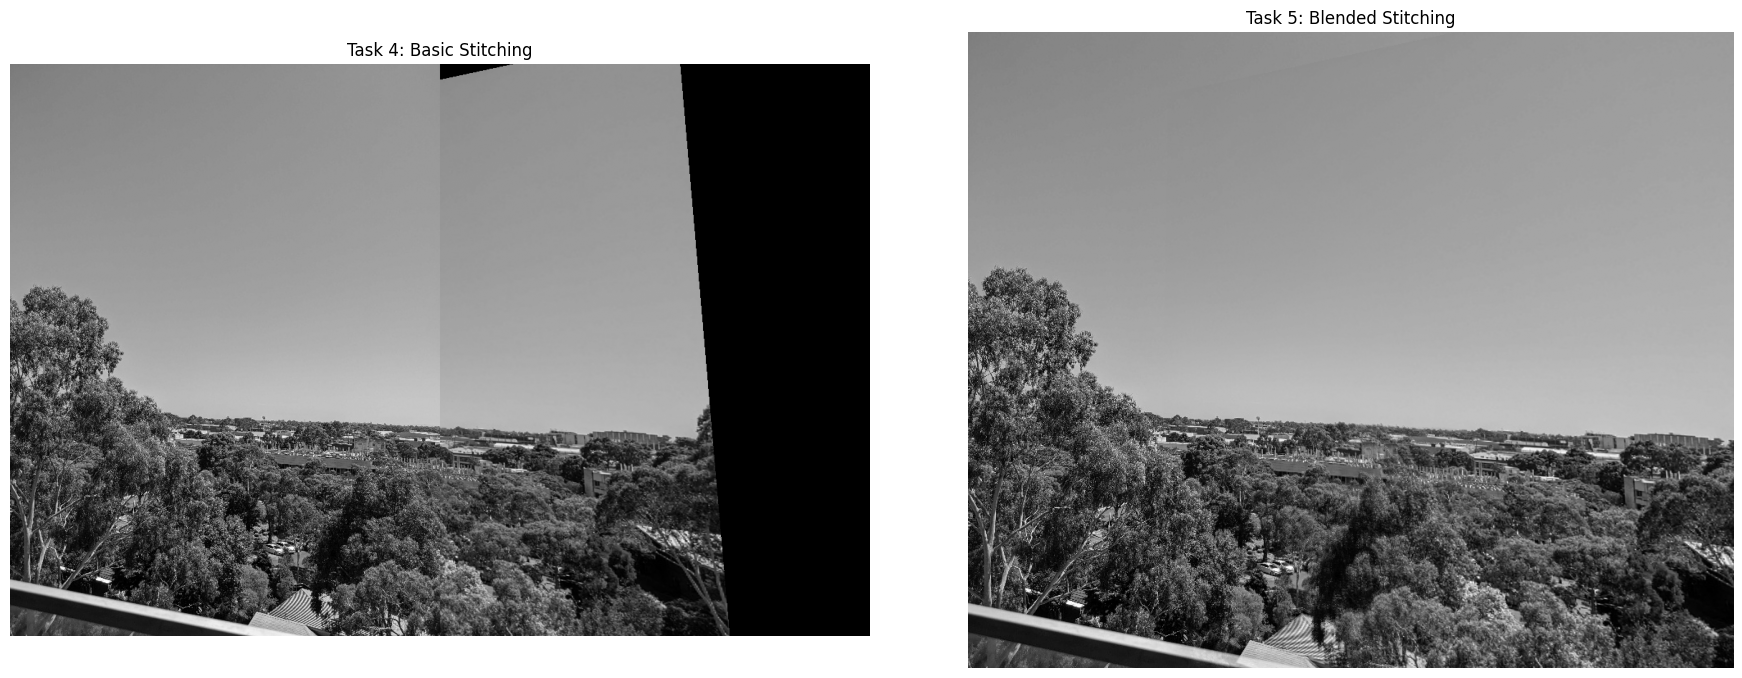

Final stitched image saved to: stitched_final.png


In [29]:
# -- Display comparison --
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(stitched, cmap='gray')
axes[0].set_title('Task 4: Basic Stitching')
axes[0].axis('off')
axes[1].imshow(stitched_blended_cropped, cmap='gray')
axes[1].set_title('Task 5: Blended Stitching')
plt.tight_layout()
plt.axis('off')
plt.show()

cv2.imwrite('stitched_final.png', stitched_blended_cropped)
print("Final stitched image saved to: stitched_final.png")


# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

In [12]:
# Write your code here

In [13]:
# Show results here





# Discussion:

Write a brief (600 word max) report describing how you solved each task, interpreting the results and pointing to any insights gained along the way. For example, you may wish to explain what a homography is, the conditions under which it can be used. Analyse the stitched images and explain any interesting artifacts you may see and why these occur. You should discuss the reasons for the presence of the image seam, and the strategies you used to improve this, pointing to the theory you have learned in class that guided your solution. Finally, explain any changes you made to the code to apply it to your own images. 

